# Container Resource Paths on Neurodesk

### A Nipype walkthrough, with SLURM scaling

**Author**: Monika Doeirg

**Date**: 08 May 2026

**License:**
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** This notebook uses neuroimaging tools from Neurocontainers; those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

**Use of AI:** This notebook was generated with assistance from *Anthropic's Claude (via Claude Code)* across several iterations and then revised by the author. The author reviewed the final content and takes responsibility for it.

### Citation and Resources

#### Tools included in this workflow

**FSL**
- Jenkinson, M., Beckmann, C. F., Behrens, T. E. J., Woolrich, M. W., & Smith, S. M. (2012). FSL. *NeuroImage*, 62(2), 782–790. [https://doi.org/10.1016/j.neuroimage.2011.09.015](https://doi.org/10.1016/j.neuroimage.2011.09.015)

- Smith S. M. (2002). Fast robust automated brain extraction. Human brain mapping, 17(3), 143–155. [https://doi.org/10.1002/hbm.10062](https://doi.org/10.1002/hbm.10062)

**ANTs**
- Tustison, N.J., Cook, P.A., Holbrook, A.J. et al. The ANTsX ecosystem for quantitative biological and medical imaging. Sci Rep 11, 9068 (2021). [https://doi.org/10.1038/s41598-021-87564-6](https://doi.org/10.1038/s41598-021-87564-6)
- N. J. Tustison et al., "N4ITK: Improved N3 Bias Correction," in IEEE Transactions on Medical Imaging, vol. 29, no. 6, pp. 1310-1320, June 2010, doi: [10.1109/TMI.2010.2046908](https://doi.org/10.1109/TMI.2010.2046908)

**SPM12**
- Friston, K. J., et al. (2007). *Statistical Parametric Mapping: The Analysis of Functional Brain Images.* Elsevier/ Academic Press.
- [Online Book](https://www.fil.ion.ucl.ac.uk/spm/doc/books/spm/Statistical_Parametric_Mapping_The_Analysis_of_Functional_Brain_Images.pdf)

**Nipype**
- Gorgolewski K, Burns CD, Madison C, Clark D, Halchenko YO, Waskom ML and Ghosh SS (2011) Nipype: A Flexible, Lightweight and Extensible Neuroimaging Data Processing Framework in Python. Front. Neuroinform. 5:13. doi: [10.3389/fninf.2011.00013](https://doi.org/10.3389/fninf.2011.00013)


#### Workflows this work is based on

- Notter, M. P. (2018). handson_preprocessing.ipynb — PyBrain Workshop, Nipype Tutorial. [handson_preprocessing.ipynb](https://github.com/miykael/workshop_pybrain/blob/master/workshop/nipype_tutorial/notebooks/handson_preprocessing.ipynb). The workflow design here follows Notter's preprocessing recipe; the path-resolution approach is adapted for Neurodesk's container layout.

##### Related discussion

- Neurodesk discussion #745 — diagnosis of hardcoded SPM/FSL paths in Notter's tutorial when run on Neurodesk: [https://github.com/orgs/neurodesk/discussions/745](https://github.com/orgs/neurodesk/discussions/745)

#### Dataset
- Gorgolewski KJ, Storkey A, Bastin ME, Whittle IR, Wardlaw JM, and Pernet CR (2022). A test-retest fMRI dataset for motor, language and spatial attention functions. . OpenNeuro. [Dataset] [doi:10.18112/openneuro.ds000114.v1.0.2](https://openneuro.org/datasets/ds000114)

## Introduction

On Neurodesk, every tool runs out of a versioned Singularity container at a slightly different path (different version dates, different versions), so hardcoded resource paths like `/opt/spm12-r7219/spm12_mcr/spm12/tpm/TPM.nii` will break. Recognising hardcoded paths and translating them into the Neurodesk equivalent is the first thing to do when porting any non-trivial workflow here.

This notebook covers:

1. **A general recipe for finding container-internal resource files** (such as `TPM.nii`, `MNI152_T1_2mm_brain.nii.gz`, or `bbr.sch`). One small helper, used three times — for the SPM tissue probability map, FSL's MNI152 template, and FSL's BBR schedule file.

2. **Scaling the workflow across the cluster with Nipype's SLURM execution plugin.** Nipype can submit each Node as its own SLURM job, with cluster-level parallelism, by changing one argument to `wf.run(...)`.

The pipeline itself is a small but realistic anatomical preprocessing chain: 

```
ANTs N4 bias correction → FSL BET → SPM NewSegment → BBR registration of fMRI to T1 → linear registration of T1 to MNI152.
```

#### What this notebook deliberately leaves out

The pipeline above is intentionally simplified to keep the focus on Neurodesk-specific patterns (path resolution, multi-tool composition, SLURM execution). A production preprocessing pipeline would normally also include steps like:

- **Motion correction** (e.g. FSL `MCFLIRT`, SPM `Realign`) — would normally precede the mean-BOLD step. Skipping it lets the functional branch reduce to a single mean image.
- **Nonlinear registration to MNI** (e.g. FSL `FNIRT` or ANTs `SyN`) — would follow the linear `FLIRT` step shown here. Linear-only is good enough for a tutorial overlay.
- **Slice-timing correction**, **spatial smoothing**, **temporal high-pass filtering**, **distortion correction** — none included.

The focus here is the path-handling and execution-plugin patterns, not a turnkey preprocessing pipeline.

## Table of contents

 [1. Load software tools and import python libraries](#1.-Load-software-tools-and-import-python-libraries)  
 [2. The container-resource-path helper](#2.-The-container-resource-path-helper)  
 [3. Data Preparation](#3.-Data-Preparation)  
 [4. Analysis: build and run the Nipype workflow](#4.-Analysis:-build-and-run-the-Nipype-workflow)  
 [5. Quality control](#5.-Quality-control)  
 [6. Scaling with Nipype's SLURM execution plugin](#6.-Scaling-with-Nipype's-SLURM-execution-plugin)  

## 1. Load software tools and import python libraries

We pin explicit versions so the notebook is reproducible. SPM12 in Neurodesk ships as the **standalone** version (compiled with MATLAB Compiler Runtime — no full MATLAB licence required).

In [1]:
# Load the three neuroimaging tools we'll use.
# Versions are pinned so the notebook is reproducible.
import module
await module.load('fsl/6.0.7.18')
await module.load('ants/2.5.3')
await module.load('spm12/r7771')
await module.list()

['fsl/6.0.7.18', 'ants/2.5.3', 'spm12/r7771']

`nipype`, `ipyniivue`, `matplotlib` and `datalad` are pre-installed in the Neurodesk base image. We `pip install` `nilearn` for the QC plots at the end.

In [2]:
%%capture
!pip install nilearn

In [3]:
# Standard library
import os
import shutil
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
from nilearn import plotting
from ipyniivue import NiiVue 
from IPython.display import Image, display

# Nipype
from nipype import Node, Workflow
from nipype.interfaces import ants, fsl, spm
from nipype.interfaces.utility import Function, IdentityInterface
from nipype.algorithms.misc import Gunzip

In [4]:
fsl.FSLCommand.set_default_output_type('NIFTI_GZ')
print(fsl.FSLCommand._output_type) 

NIFTI_GZ


## 2. The container-resource-path helper

Many neuroimaging tasks need files that ship inside a tool's installation — SPM's tissue probability map (`TPM.nii`), FSL's MNI152 reference template(`$FSLDIR/data/standard/MNI152_T1_2mm_brain.nii.gz`), FSL's BBR schedule (`$FSLDIR/etc/flirtsch/bbr.sch`), etc.
                             
As mentioned, on Neurodesk, every tool runs out of a Singularity container at a versioned path like `/cvmfs/.../containers/fsl_6.0.7.18_20250928/`, so those tool-internal paths aren't on the host filesystem at their "usual" location. The container directory is mounted as `<containerdir>/<containerdir>.simg/` (transparent singularity), and *inside* that mount the original file structure (`/opt/fsl-6.0.7.18/...`) lives. To use any of these files from a host-side process (a Nipype workflow, a custom Python script, a bash command), you need to translate the tool's internal path into its Neurodesk-host-visible equivalent inside the `.simg` mount.

So a hardcoded path like `/opt/fsl-6.0.7.18/data/standard/MNI152_T1_2mm_brain.nii.gz` won't resolve on the host filesystem — you need:

```
/cvmfs/.../containers/fsl_6.0.7.18_20250928/fsl_6.0.7.18_20250928.simg/opt/fsl-6.0.7.18/data/standard/MNI152_T1_2mm_brain.nii.gz
```

Also note: the date suffix (`_20250928`) is tied to a specific container build and can change when the container is rebuilt (so even the absolute path on `/cvmfs` isn't necessarily stable).

### The recipe

After `module load <tool>/<version>`, the tool's wrapper binary is on `PATH`. `shutil.which("<tool>")` returns the wrapper path; its parent directory is the container directory; that directory's `name` matches the `.simg` mount point. Resource files inside the container can be addressed by appending their *original* internal path.

In [5]:
def container_resource(tool: str, internal_path: str) -> Path:
    """Return the host path to a file inside a Neurodesk container.

    Parameters
    ----------
    tool
        Name of the tool's launcher binary (e.g. 'fsl', 'spm12', 'antsRegistration').
        Must be on PATH after `module load`.
    internal_path
        The file's path *inside* the container (e.g. 'opt/fsl-6.0.7.18/data/standard/MNI152_T1_2mm_brain.nii.gz').

    Returns
    -------
    Path to the file on the host filesystem (inside the .simg mount).
    """
    launcher = shutil.which(tool)
    if launcher is None:
        raise RuntimeError(f"'{tool}' not found on PATH — did you `module load` it?")
    container_dir = Path(launcher).parent
    return container_dir / f"{container_dir.name}.simg" / internal_path

### Resolve the three paths we'll need

All three files live inside the container's `.simg` mount on `/cvmfs`. The helper computes their host-visible paths from the loaded module so you don't need to know the version-dated container directory by hand.

In [6]:
# 1. SPM12 tissue probability map — used by NewSegment.
SPM_TPM = container_resource('spm12', 'opt/spm12/spm12_mcr/spm12/spm12/tpm/TPM.nii')
# 2. FSL MNI152 reference template — used by FLIRT for T1→MNI registration.
FSL_MNI = container_resource('fsl', 'opt/fsl-6.0.7.18/data/standard/MNI152_T1_2mm_brain.nii.gz')
# 3. FSL BBR schedule — used by FLIRT for fMRI→T1 BBR registration.
#    `etc/flirtsch/` is FSL's canonical runtime location ($FSLDIR/etc/flirtsch/...).
FSL_BBR = container_resource('fsl', 'opt/fsl-6.0.7.18/etc/flirtsch/bbr.sch')

for label, p in [('SPM TPM', SPM_TPM), ('FSL MNI152', FSL_MNI), ('FSL bbr.sch', FSL_BBR)]:
    exists = '✓' if p.exists() else '✗ MISSING'
    print(f"{exists}  {label:14s} {p}")

✓  SPM TPM        /cvmfs/neurodesk.ardc.edu.au/containers/spm12_r7771_20230609/spm12_r7771_20230609.simg/opt/spm12/spm12_mcr/spm12/spm12/tpm/TPM.nii
✓  FSL MNI152     /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.18_20250928/fsl_6.0.7.18_20250928.simg/opt/fsl-6.0.7.18/data/standard/MNI152_T1_2mm_brain.nii.gz
✓  FSL bbr.sch    /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.18_20250928/fsl_6.0.7.18_20250928.simg/opt/fsl-6.0.7.18/etc/flirtsch/bbr.sch


:::{tip}
**Finding an unfamiliar internal path.** The container's `.simg` mount is just a directory tree on the host filesystem, so you can search it with plain `find` — straight from this notebook (see the next cell), or from a terminal. The path printed during `module load` also tells you the top-level container mount.
:::

In [7]:
# Find a resource by filename inside a Neurodesk container.
# `container_resource('fsl', '')` returns the root of the FSL container's .simg mount,
# which we can hand straight to `find`. The `-path` filter limits to FSL's canonical
# runtime location ($FSLDIR/etc/flirtsch/...); `-not -path "*pkgs*"` skips conda's
# package cache, which keeps byte-identical duplicates of every shipped file.
fsl_simg = container_resource('fsl', '')
!find {fsl_simg}/opt -path "*etc/flirtsch*" -not -path "*pkgs*" -name "bbr.sch" 2>/dev/null

/cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.18_20250928/fsl_6.0.7.18_20250928.simg/opt/fsl-6.0.7.18/etc/flirtsch/bbr.sch


## 3. Data Preparation

We use **ds000114** (a finger/foot/lips motor task), pulling one subject's T1 and one short functional run via DataLad.

In [8]:
%%bash
# Install ds000114 from OpenNeuro (lightweight — only metadata is fetched).
[ -d ds000114 ] || datalad install https://github.com/OpenNeuroDatasets/ds000114.git

cd ds000114
# Get the actual NIfTI data for one subject + one short functional run.
datalad get sub-01/ses-test/anat/sub-01_ses-test_T1w.nii.gz
datalad get sub-01/ses-test/func/sub-01_ses-test_task-fingerfootlips_bold.nii.gz

ls -lh sub-01/ses-test/anat/ sub-01/ses-test/func/

[INFO] Attempting a clone into /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114 
[INFO] Attempting to clone from https://github.com/OpenNeuroDatasets/ds000114.git to /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114 
[INFO] Start enumerating objects 
[INFO] Start counting objects 
[INFO] Start compressing objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/OpenNeuroDatasets/ds000114.git/config download failed: Not Found 
[INFO] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
| 		datalad siblings -d "/home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114" enable -s s3-PRIVATE 


install(ok): /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114 (dataset)
get(ok): sub-01/ses-test/anat/sub-01_ses-test_T1w.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-01/ses-test/func/sub-01_ses-test_task-fingerfootlips_bold.nii.gz (file) [from s3-PUBLIC...]
sub-01/ses-test/anat/:
total 4.0K
lrwxrwxrwx 1 jovyan users 143 May  7 06:57 sub-01_ses-test_T1w.nii.gz -> ../../../.git/annex/objects/QP/jm/MD5E-s8677710--d6820f6cb8fb965e864419c14f6a22d5.nii.gz/MD5E-s8677710--d6820f6cb8fb965e864419c14f6a22d5.nii.gz

sub-01/ses-test/func/:
total 28K
lrwxrwxrwx 1 jovyan users  145 May  7 06:57 sub-01_ses-test_task-covertverbgeneration_bold.nii.gz -> ../../../.git/annex/objects/mx/zJ/MD5E-s22944165--71b1eda077a1003a177552f6c380323a.nii.gz/MD5E-s22944165--71b1eda077a1003a177552f6c380323a.nii.gz
lrwxrwxrwx 1 jovyan users  145 May  7 06:57 sub-01_ses-test_task-fingerfootlips_bold.nii.gz -> ../../../.git/annex/objects/k6/4f/MD5E-s24454931--e9ab535d84a922b0c7ed52461244cf47.n

## 4. Analysis: build and run the Nipype workflow

### Pipeline

```
T1w ─► N4 (ANTs) ─► BET (FSL) ─┬─► FLIRT 12 DOF ─► T1 in MNI152
                               │
                               └─► SPM NewSegment ─► c2 (WM) ─► threshold ─► WM mask
                                                                              │
fMRI 4D ─► MeanImage (FSL) ─► BOLD ref ─────────────────────────► FLIRT BBR  ◄┘
                                                                  (uses bbr.sch + WM mask)
```

Each Nipype `Node` wraps one external command. The `Workflow` declares how their outputs feed each others' inputs.

### Pick a subject

Set the subject identifier once here. To process a different subject from `ds000114`, change this value and re-run from this cell down. Make sure to download the required subjects first. 

In [9]:
# Subject identifier 
subject_id = '01'

In [10]:
# Resolve input file paths from the parameter.
#data_dir = Path('ds000114') / f'sub-{subject_id}' / 'ses-test'
data_dir = (Path('ds000114') / f'sub-{subject_id}' / 'ses-test').resolve()
t1_path = data_dir / 'anat' / f'sub-{subject_id}_ses-test_T1w.nii.gz'
bold_path = data_dir / 'func' / f'sub-{subject_id}_ses-test_task-fingerfootlips_bold.nii.gz'
assert t1_path.exists() and bold_path.exists(), 'input files not found — check subject_id'
print('T1: ', t1_path)
print('BOLD:', bold_path)

T1:  /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114/sub-01/ses-test/anat/sub-01_ses-test_T1w.nii.gz
BOLD: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/ds000114/sub-01/ses-test/func/sub-01_ses-test_task-fingerfootlips_bold.nii.gz


### Build the Nipype nodes

In [11]:
# --- Anatomical chain: N4 → BET → SPM NewSegment ---

n4 = Node(ants.N4BiasFieldCorrection(
    dimension=3,
    save_bias=False,
), name='n4')

gunzip_t1 = Node(Gunzip(), name='gunzip_t1')

bet = Node(fsl.BET(
    robust=True,
    frac=0.5,
), name='bet')

# SPM NewSegment with the standard 6-tissue specification.
# `tissues` is a list of (TPM-with-class, num_gaussians, (native, dartel), (modulated, unmodulated)).
tissues = [
    ((str(SPM_TPM), 1), 1, (True,  False), (False, False)),  # GM
    ((str(SPM_TPM), 2), 1, (True,  False), (False, False)),  # WM
    ((str(SPM_TPM), 3), 2, (True,  False), (False, False)),  # CSF
    ((str(SPM_TPM), 4), 3, (False, False), (False, False)),  # bone
    ((str(SPM_TPM), 5), 4, (False, False), (False, False)),  # soft tissue
    ((str(SPM_TPM), 6), 2, (False, False), (False, False)),  # background
]
segment = Node(spm.NewSegment(tissues=tissues), name='segment')

stty: 'standard input': Inappropriate ioctl for device


In [12]:
# --- Threshold the WM probability map (c2) into a binary WM mask. ---
# We use FSL's fslmaths (via Nipype's fsl.Threshold). We will also need a one-line
# helper to extract c2 from NewSegment's nested-list output
# [[c1], [c2], [c3], ...] — applied inline in the workflow connection below.

def pick_c2(class_images):
    """Pick the WM probability map (c2) from NewSegment's native_class_images."""
    return class_images[1][0]

wm_thresh = Node(fsl.Threshold(thresh=0.5, args='-bin'), name='wm_thresh')

In [13]:
# --- Functional reference: mean of the 4D BOLD series. ---

bold_mean = Node(fsl.MeanImage(dimension='T'), name='bold_mean')

# --- T1 → MNI152 (12 DOF affine, uses container-resolved MNI reference). ---

flirt_mni = Node(fsl.FLIRT(
    reference=str(FSL_MNI),
    dof=12,
    cost='corratio',
), name='flirt_mni')

# --- fMRI → T1 (initial 6 DOF registration, then BBR refinement). ---

flirt_init = Node(fsl.FLIRT(
    dof=6,
    cost='corratio',
), name='flirt_init')

flirt_bbr = Node(fsl.FLIRT(
    dof=6,
    cost='bbr',
    schedule=str(FSL_BBR),  # ← container-resolved BBR schedule
), name='flirt_bbr')

### Connect the workflow

In [14]:
wf = Workflow(name='nipype_preproc', base_dir=str(Path.cwd() / 'work'))

wf.connect([
    # T1 anatomical chain
    (n4,        bet,        [('output_image', 'in_file')]),
    (n4,        gunzip_t1, [('output_image', 'in_file')]),
    (gunzip_t1, segment,   [('out_file',     'channel_files')]),
    # Apply pick_c2 inline so wm_thresh receives a single file path (not the nested list).
    (segment,   wm_thresh,  [(('native_class_images', pick_c2), 'in_file')]),

    # T1 brain → MNI152
    (bet,       flirt_mni,  [('out_file', 'in_file')]),

    # fMRI mean → T1 brain (initial), then BBR with WM mask
    (bold_mean, flirt_init, [('out_file', 'in_file')]),
    (bet,       flirt_init, [('out_file', 'reference')]),
    (bold_mean, flirt_bbr,  [('out_file', 'in_file')]),
    (bet,       flirt_bbr,  [('out_file', 'reference')]),
    (flirt_init, flirt_bbr, [('out_matrix_file', 'in_matrix_file')]),
    (wm_thresh, flirt_bbr,  [('out_file', 'wm_seg')]),
])

# Wire the parameters into the workflow inputs.
n4.inputs.input_image = str(t1_path)
bold_mean.inputs.in_file = str(bold_path)

260507-06:57:30,972 nipype.workflow INFO:
	 Generated workflow graph: /home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/work/nipype_preproc/graph.png (graph2use=colored, simple_form=True).


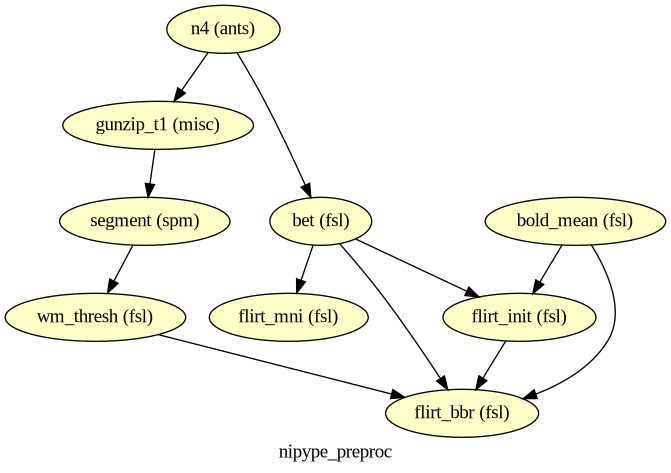

In [15]:
# Render the workflow graph for inspection.
wf.write_graph(graph2use='colored', format='png', simple_form=True)
display(Image(filename=str(Path(wf.base_dir) / wf.name / 'graph.png')))

### Run the workflow

Locally we use the `MultiProc` plugin so independent nodes (e.g. NewSegment and the FLIRT chain) run in parallel.

In [16]:
wf.run(plugin='MultiProc', plugin_args={'n_procs': 4})

260507-06:57:30,987 nipype.workflow INFO:
	 Workflow nipype_preproc settings: ['check', 'execution', 'logging', 'monitoring']
260507-06:57:30,992 nipype.workflow INFO:
	 Running in parallel.
260507-06:57:30,995 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 106.12/106.12, Free processors: 4/4, Free GPU slot:0/0.
260507-06:57:31,145 nipype.workflow INFO:
	 [Node] Setting-up "nipype_preproc.n4" in "/home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/work/nipype_preproc/n4".
260507-06:57:31,145 nipype.workflow INFO:
	 [Node] Setting-up "nipype_preproc.bold_mean" in "/home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/work/nipype_preproc/bold_mean".
260507-06:57:31,149 nipype.workflow INFO:
	 [Node] Executing "n4" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>
260507-06:57:31,149 nipype.workflow INFO:
	 [Node] Executing "bold_mean" <nipype.interfaces.fsl.maths.MeanImage>
260507-06:57:32,996 nipype.workfl

stty: 'standard input': Inappropriate ioctl for device


260507-06:59:47,4 nipype.workflow INFO:
	 [Job 6] Completed (nipype_preproc.segment).
260507-06:59:47,5 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 106.12/106.12, Free processors: 4/4, Free GPU slot:0/0.
260507-06:59:47,120 nipype.workflow INFO:
	 [Node] Setting-up "nipype_preproc.wm_thresh" in "/home/jovyan/Git_repositories/neurodeskedu/books/examples/workflows/work/nipype_preproc/wm_thresh".
260507-06:59:47,123 nipype.workflow INFO:
	 [Node] Executing "wm_thresh" <nipype.interfaces.fsl.maths.Threshold>
260507-06:59:48,802 nipype.workflow INFO:
	 [Node] Finished "wm_thresh", elapsed time 1.676912s.
260507-06:59:49,4 nipype.workflow INFO:
	 [Job 7] Completed (nipype_preproc.wm_thresh).
260507-06:59:49,6 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 106.12/106.12, Free processors: 4/4, Free GPU slot:0/0.
260507-06:59:49,121 nipype.workflow INFO:
	 [Node] Setting-up "nipype_preproc.flirt_bbr" in "/hom

## 5. Quality control

Two visual checks: T1 registered to MNI152 (linear), and fMRI reference registered to T1 via BBR.

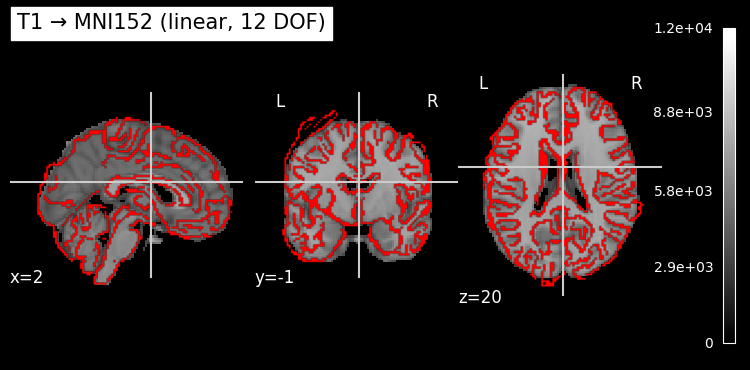

In [17]:
work = Path(wf.base_dir) / wf.name

t1_in_mni = next((work / 'flirt_mni').glob('*.nii.gz'))
bold_in_t1 = next((work / 'flirt_bbr').glob('*.nii.gz'))
#t1_brain = next((work / 'bet').glob('*.nii.gz'))

display = plotting.plot_anat(
    str(FSL_MNI), title='T1 → MNI152 (linear, 12 DOF)', display_mode='ortho')
display.add_edges(str(t1_in_mni))
#plt.savefig('qc_t1_to_mni.png', dpi=120, bbox_inches='tight')
plt.show()


In [18]:
# Interactive BBR QC with ipyniivue.                                          
# Two volumes overlaid:                                  
#   - BOLD (registered to T1) — gray
#   - WM mask used by BBR — red, semi-transparent  
# If BBR worked, the red WM contour should sit along tissue boundaries in the BOLD.       
                         
wm_mask = next((Path(wf.base_dir) / wf.name / 'wm_thresh').glob('*.nii*'))
                                                                
nv = NiiVue()                                          
nv.load_volumes([
    {"path": str(bold_in_t1), "colormap": "gray"},
    {"path": str(wm_mask),    "colormap": "red", "opacity": 0.5}, 
])   
nv

## 6. Scaling with Nipype's SLURM execution plugin

Above we ran the workflow with the `MultiProc` plugin — Nipype's built-in plugin for parallel execution on a single machine. Nipype also has a **`SLURM`** plugin that submits each Node as its own SLURM job.

The only change to the run command is the `plugin` argument:

```python
wf.run(
    plugin='SLURM',
    plugin_args={
        'sbatch_args': '--mem=16G --time=01:00:00 --cpus-per-task=4',
    },
)
```

What this does:

- **Each Nipype Node becomes one `sbatch` job.** Independent nodes (e.g. `flirt_mni` and the BBR sub-chain) run in parallel as separate cluster jobs.
- **Dependencies are honoured automatically.** Nipype waits for parent jobs to finish before submitting children — you do not write the dependency DAG yourself.
- **Same workflow code, different scheduler.** `wf.connect(...)`, the Nodes, and all their inputs stay exactly as they are above.
- **No `.sbat` file required.** Nipype auto-generates a basic sbatch template per Node. Pass a custom `template` file (via `plugin_args={'template': 'mytemplate.sh', ...}`) only if you have non-standard cluster requirements (e.g. account names, partitions, GRES).

### Per-node resource customisation

`sbatch_args` is passed to *every* sbatch invocation. If individual nodes need different resources, set them on the Node directly:

```python
segment.plugin_args = {'sbatch_args': '--mem=24G --time=00:30:00'}
```

Per-node `sbatch_args` are concatenated with the workflow-level defaults; for any flag specified twice (e.g. `--mem`), SLURM uses the later (per-node) value.

### Requirements

- The kernel running this notebook must be on a host where `sbatch` is available (login node, or a compute node with the SLURM client).
- For an alternative pattern — a single Papermill-driven array job that fans out per-subject — see [`papermill-slurm-submission-example.ipynb`](papermill-slurm-submission-example.ipynb). The two approaches are complementary: Nipype's plugin is finer-grained (one job per node), Papermill's array is coarser-grained (one job per subject).

#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [19]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-05-07T07:00:35.682607+00:00

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-177-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 30
Architecture: 64bit

IPython   : 9.12.0
ipyniivue : 2.4.4
matplotlib: 3.10.9
nibabel   : 5.4.2
nilearn   : 0.13.1
nipype    : 1.11.0
numpy     : 2.4.4

Neurodesktop version: 2026-05-04
